# 03 — Team-Match Network Feature Table

**Goal:** Build one row per team per match (128 rows total) combining passing network metrics with match metadata and advancement labels.

This dataset is the foundation for all analysis — does network structure separate quarterfinalists from eliminated teams?

**Output:** `data/processed/team_match_network_features.csv`

In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from data_loader import load_matches, load_events

DATA_DIR = Path('../data')
RAW_DIR  = DATA_DIR / 'raw'
PROC_DIR = DATA_DIR / 'processed'
FIG_DIR  = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Match metadata

Load all 64 matches. Each match gives us the two teams, score, stage, and date.

In [2]:
matches, _ = load_matches(cache_path=RAW_DIR / 'matches.csv')

print(f"Matches loaded : {len(matches)}")
print(f"Stage breakdown:")
print(matches['stage_label'].value_counts().to_string())
print()

meta_cols = ['match_id', 'match_date', 'stage_label',
             'home_team', 'away_team', 'home_score', 'away_score']
matches[meta_cols].head(6)

Matches loaded : 64
Stage breakdown:
stage_label
group              48
R16                 8
QF                  4
SF                  2
Final               1
3rd Place Final     1



,match_id,match_date,stage_label,home_team,away_team,home_score,away_score
0,3857276,2022-12-01,group,Canada,Morocco,1,2
1,3857271,2022-11-21,group,England,Iran,6,2
2,3857296,2022-12-01,group,Croatia,Belgium,0,0
3,3857274,2022-11-25,group,Netherlands,Ecuador,1,1
4,3857255,2022-12-01,group,Japan,Spain,2,1
5,3857272,2022-11-25,group,England,United States,0,0


## 2. Network metrics per team-match

For each of the 128 team-match combinations, compute:
- **Completed passes** — total passes that reached a teammate
- **Unique passing pairs** — directed passer→recipient connections
- **Network density** — actual pairs / possible pairs (how connected is the network?)
- **Most involved player** — highest passes sent + received
- **Top player reliance** — that player's involvement share (how hub-dependent is the team?)
- **Top connection** — most frequent passer→recipient link and its count
- **Final-third entries** — passes that started outside the final third and ended inside it (x < 80 → x ≥ 80)

In [3]:
SET_PIECE_TYPES = {'Corner', 'Free Kick', 'Throw-in', 'Kick Off', 'Goal Kick'}

def _coord(v, i):
    """Extract coordinate at index i from a list, tuple, or numpy array."""
    try: return float(v[i])
    except: return None


def compute_network_metrics(ev, team):
    """
    Compute all passing-network metrics for one team in one match.

    Returns a dict of metrics, or None if there are no completed passes.
    """
    tp = ev[
        (ev['type'] == 'Pass') &
        (ev['pass_outcome'].isna()) &
        (ev['team'] == team)
    ].copy()

    # --- coordinates ---
    tp['x']  = tp['location'].apply(lambda v: _coord(v, 0))

    has_end = 'pass_end_location' in tp.columns
    if has_end:
        tp['ex']    = tp['pass_end_location'].apply(lambda v: _coord(v, 0))
        # Final-third entry: pass started outside final third, ended inside
        tp['is_ft'] = (tp['x'] < 80) & (tp['ex'] >= 80)
    else:
        tp['is_ft'] = False

    completed = tp.dropna(subset=['player', 'pass_recipient'])
    if len(completed) == 0:
        return None

    # --- node involvement ---
    sent_ct    = completed.groupby('player').size()
    recv_ct    = completed.groupby('pass_recipient').size()
    avg_pos    = tp.dropna(subset=['x']).groupby('player')['x'].count()  # proxy for appearing on pitch
    all_players = set(avg_pos.index)

    inv    = {p: int(sent_ct.get(p, 0)) + int(recv_ct.get(p, 0)) for p in all_players}
    ranked = sorted(inv.items(), key=lambda kv: -kv[1])

    # --- edge list ---
    edges = []
    for (passer, recip), grp in completed.groupby(['player', 'pass_recipient']):
        edges.append({
            's':  passer,
            't':  recip,
            'w':  len(grp),
            'ft': int(grp['is_ft'].sum()) if has_end else 0,
        })

    # --- team-level metrics ---
    n_nodes  = len(all_players)
    n_edges  = len(edges)
    total    = len(completed)
    max_poss = n_nodes * (n_nodes - 1) if n_nodes > 1 else 1
    density  = n_edges / max_poss if max_poss else 0

    most_inv  = ranked[0][0] if ranked else ''
    most_tot  = ranked[0][1] if ranked else 0
    total_inv = sum(inv.values())
    top_rel   = most_tot / total_inv if total_inv else 0

    top_e     = max(edges, key=lambda e: e['w']) if edges else None
    top_pair  = (f"{top_e['s'].split()[-1]} \u2192 {top_e['t'].split()[-1]}") if top_e else ''
    total_ft  = sum(e['ft'] for e in edges) if has_end else np.nan

    return {
        'completed_passes':     total,
        'unique_passing_pairs': n_edges,
        'num_players':          n_nodes,
        'network_density':      round(density, 4),
        'most_involved_player': most_inv,
        'top_player_reliance':  round(top_rel, 4),
        'top_connection':       top_pair,
        'top_connection_count': top_e['w'] if top_e else 0,
        'final_third_entries':  int(total_ft) if not np.isnan(total_ft) else np.nan,
    }

In [4]:
rows = []

for _, match_row in matches.iterrows():
    mid        = int(match_row['match_id'])
    home_team  = str(match_row['home_team'])
    away_team  = str(match_row['away_team'])
    home_score = int(match_row['home_score'])
    away_score = int(match_row['away_score'])
    stage      = str(match_row.get('stage_label', ''))
    date       = str(match_row.get('match_date', ''))
    match_name = f"{home_team} vs {away_team}"

    try:
        ev = load_events(mid, cache_dir=RAW_DIR / 'events')
    except Exception as exc:
        print(f"  Could not load match {mid}: {exc}")
        continue

    for team, opp, gf, ga in [
        (home_team, away_team, home_score, away_score),
        (away_team, home_team, away_score, home_score),
    ]:
        metrics = compute_network_metrics(ev, team)
        if metrics is None:
            continue

        if gf > ga:   result = 'W'
        elif gf < ga: result = 'L'
        else:         result = 'D'

        rows.append({
            'match_id':      mid,
            'match_name':    match_name,
            'date':          date,
            'stage':         stage,
            'team':          team,
            'opponent':      opp,
            'goals_for':     gf,
            'goals_against': ga,
            'match_result':  result,
            **metrics,
        })

feat_df = pd.DataFrame(rows)
print(f"Feature table built: {feat_df.shape[0]} rows × {feat_df.shape[1]} columns")
print(f"Expected: 128 rows (64 matches × 2 teams)")
feat_df[['team', 'opponent', 'stage', 'match_result',
         'completed_passes', 'network_density',
         'most_involved_player', 'top_player_reliance',
         'final_third_entries']].head(6)

Feature table built: 128 rows × 18 columns
Expected: 128 rows (64 matches × 2 teams)


,team,opponent,stage,match_result,completed_passes,network_density,most_involved_player,top_player_reliance,final_third_entries
0,Canada,Morocco,group,L,480,0.5833,Kamal Miller,0.1656,43
1,Morocco,Canada,group,W,310,0.4762,Achraf Hakimi Mouh,0.1472,12
2,England,Iran,group,W,746,0.5917,John Stones,0.1535,55
3,Iran,England,group,L,163,0.3958,Mehdi Taremi,0.1138,14
4,Croatia,Belgium,group,D,514,0.5934,Marcelo Brozović,0.1469,36
5,Belgium,Croatia,group,D,543,0.5833,Toby Alderweireld,0.1492,38


## 3. Advancement labels

Add three binary/categorical columns:
- **`advanced_from_group`** — 1 if the team played in the Round of 16
- **`reached_qf`** — 1 for the 8 quarterfinalists
- **`stage_reached`** — furthest stage the team played in

In [5]:
# Teams confirmed to have reached the quarterfinals
QF_TEAMS = frozenset([
    'Argentina', 'Netherlands', 'Croatia', 'Brazil',
    'England', 'France', 'Morocco', 'Portugal',
])

# Teams that advanced from the group stage = those who played in R16
r16_matches = matches[matches['stage_label'] == 'R16']
r16_teams   = set(r16_matches['home_team'].tolist() + r16_matches['away_team'].tolist())
print(f"Teams that advanced from groups: {len(r16_teams)}")

# Furthest stage each team reached
STAGE_RANK = {
    'group': 1, 'R16': 2, 'QF': 3, 'SF': 4,
    '3rd Place Final': 5, 'Final': 6,
}
STAGE_LABEL = {
    1: 'Group Stage', 2: 'Round of 16', 3: 'Quarter-final',
    4: 'Semi-final',  5: '3rd Place',   6: 'Final',
}

def get_stage_reached(team):
    team_matches = matches[
        (matches['home_team'] == team) | (matches['away_team'] == team)
    ]
    max_rank = max(
        (STAGE_RANK.get(str(s), 0) for s in team_matches['stage_label']),
        default=0
    )
    return STAGE_LABEL.get(max_rank, 'Unknown')


feat_df['advanced_from_group'] = feat_df['team'].apply(lambda t: 1 if t in r16_teams   else 0)
feat_df['reached_qf']          = feat_df['team'].apply(lambda t: 1 if t in QF_TEAMS    else 0)
feat_df['stage_reached']       = feat_df['team'].apply(get_stage_reached)

print()
print("Label counts:")
print(f"  advanced_from_group = 1 : {feat_df['advanced_from_group'].sum()} team-match rows")
print(f"  reached_qf = 1          : {feat_df['reached_qf'].sum()} team-match rows")
print()
print("Stage reached distribution:")
print(feat_df.groupby('stage_reached')['team'].nunique().sort_values(ascending=False).to_string())

Teams that advanced from groups: 16

Label counts:
  advanced_from_group = 1 : 80 team-match rows
  reached_qf = 1          : 48 team-match rows

Stage reached distribution:
stage_reached
Group Stage      16
Round of 16       8
Quarter-final     4
3rd Place         2
Final             2


In [6]:
# Enforce column order as specified
col_order = [
    'match_id', 'match_name', 'date', 'stage', 'team', 'opponent',
    'goals_for', 'goals_against', 'match_result',
    'completed_passes', 'unique_passing_pairs', 'num_players', 'network_density',
    'most_involved_player', 'top_player_reliance',
    'top_connection', 'top_connection_count',
    'final_third_entries',
    'advanced_from_group', 'reached_qf', 'stage_reached',
]
feat_df = feat_df[col_order]

# Save
out_path = PROC_DIR / 'team_match_network_features.csv'
feat_df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Shape: {feat_df.shape}")
print()
feat_df.head(8)

Saved: ../data/processed/team_match_network_features.csv
Shape: (128, 21)



,match_id,match_name,date,stage,team,opponent,goals_for,goals_against,match_result,completed_passes,...,num_players,network_density,most_involved_player,top_player_reliance,top_connection,top_connection_count,final_third_entries,advanced_from_group,reached_qf,stage_reached
0,3857276,Canada vs Morocco,2022-12-01,group,Canada,Morocco,1,2,L,480,...,16,0.5833,Kamal Miller,0.1656,Vitoria → Miller,20,43,0,0,Group Stage
1,3857276,Canada vs Morocco,2022-12-01,group,Morocco,Canada,2,1,W,310,...,15,0.4762,Achraf Hakimi Mouh,0.1472,Ziyech → Mouh,13,12,1,1,3rd Place
2,3857271,England vs Iran,2022-11-21,group,England,Iran,6,2,W,746,...,16,0.5917,John Stones,0.1535,Trippier → Stones,29,55,1,1,Quarter-final
3,3857271,England vs Iran,2022-11-21,group,Iran,England,2,6,L,163,...,16,0.3958,Mehdi Taremi,0.1138,Moharrami → Nourollahi,5,14,0,0,Group Stage
4,3857296,Croatia vs Belgium,2022-12-01,group,Croatia,Belgium,0,0,D,514,...,14,0.5934,Marcelo Brozović,0.1469,Kovačić → Brozović,22,36,1,1,3rd Place
5,3857296,Croatia vs Belgium,2022-12-01,group,Belgium,Croatia,0,0,D,543,...,16,0.5833,Toby Alderweireld,0.1492,Alderweireld → Meunier,27,38,0,0,Group Stage
6,3857274,Netherlands vs Ecuador,2022-11-25,group,Netherlands,Ecuador,1,1,D,457,...,15,0.5238,Nathan Aké,0.1521,Aké → Blind,26,29,1,1,Quarter-final
7,3857274,Netherlands vs Ecuador,2022-11-25,group,Ecuador,Netherlands,1,1,D,359,...,12,0.7348,Felix Eduardo Torres Caicedo,0.1427,Carabalí → Caicedo,13,20,0,0,Group Stage


## 4. QF vs non-QF comparison

Compare quarterfinalists (reached_qf = 1) against eliminated teams on five key metrics.

In [7]:
COMPARE_COLS = [
    'completed_passes',
    'unique_passing_pairs',
    'network_density',
    'top_player_reliance',
    'final_third_entries',
]

summary = (
    feat_df
    .groupby('reached_qf')[COMPARE_COLS]
    .agg(['mean', 'median'])
    .round(4)
)
summary.index = summary.index.map({0: 'Non-QF (eliminated)', 1: 'Quarterfinal+'})
summary.columns = [f"{col} ({stat})" for col, stat in summary.columns]
summary.T

reached_qf,Non-QF (eliminated),Quarterfinal+
completed_passes (mean),403.7000,501.0417
completed_passes (median),384.0000,519.5000
unique_passing_pairs (mean),115.8750,123.6667
unique_passing_pairs (median),115.0000,126.5000
network_density (mean),0.5340,0.5649
network_density (median),0.5380,0.5646
top_player_reliance (mean),0.1500,0.1449
top_player_reliance (median),0.1464,0.1440
final_third_entries (mean),30.9250,36.6667
final_third_entries (median),29.0000,36.0000


In [8]:
# Print readable findings with direction and % difference
print("=" * 72)
print("QF teams vs non-QF teams — key metric differences")
print("=" * 72)

fmt_map = {
    'completed_passes':     ('.1f', ''),
    'unique_passing_pairs':  ('.1f', ''),
    'network_density':      ('.4f', ''),
    'top_player_reliance':  ('.1%', ''),
    'final_third_entries':  ('.1f', ''),
}

labels = {
    'completed_passes':     'Completed passes   ',
    'unique_passing_pairs':  'Unique pass pairs  ',
    'network_density':      'Network density    ',
    'top_player_reliance':  'Hub reliance       ',
    'final_third_entries':  'Final-third entries',
}

for col, (fmt, _) in fmt_map.items():
    qf_mean  = feat_df[feat_df['reached_qf'] == 1][col].mean()
    non_mean = feat_df[feat_df['reached_qf'] == 0][col].mean()
    qf_med   = feat_df[feat_df['reached_qf'] == 1][col].median()
    non_med  = feat_df[feat_df['reached_qf'] == 0][col].median()
    diff     = qf_mean - non_mean
    pct      = abs(diff / non_mean * 100) if non_mean else 0
    arrow    = '▲' if diff > 0 else '▼'

    print(f"  {labels[col]}  "
          f"QF mean={format(qf_mean, fmt)}  Non-QF mean={format(non_mean, fmt)}  "
          f"{arrow} {pct:.1f}%")

print("=" * 72)

QF teams vs non-QF teams — key metric differences
  Completed passes     QF mean=501.0  Non-QF mean=403.7  ▲ 24.1%
  Unique pass pairs    QF mean=123.7  Non-QF mean=115.9  ▲ 6.7%
  Network density      QF mean=0.5649  Non-QF mean=0.5340  ▲ 5.8%
  Hub reliance         QF mean=14.5%  Non-QF mean=15.0%  ▼ 3.4%
  Final-third entries  QF mean=36.7  Non-QF mean=30.9  ▲ 18.6%


/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_22543/1088372045.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_22543/1088372045.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


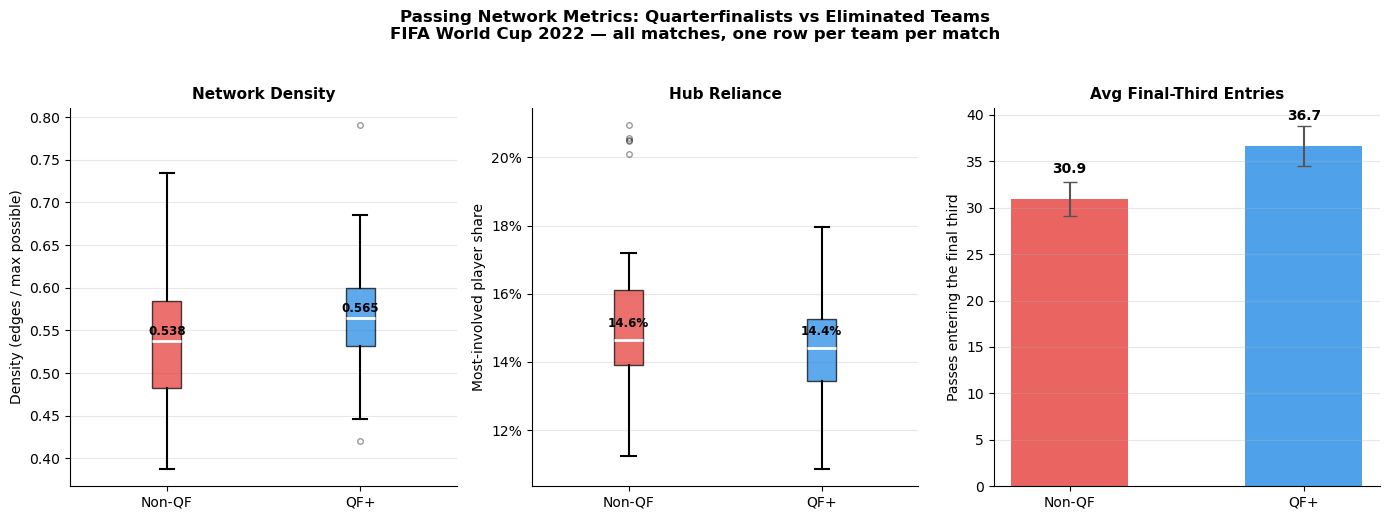

Saved: ../outputs/figures/03_qf_vs_nonqf_comparison.png


In [9]:
# ── Visual comparison ──────────────────────────────────────────────────────
QF_COLOR  = '#1E88E5'   # blue  — QF teams
ELM_COLOR = '#E53935'   # red   — eliminated teams

qf_data  = feat_df[feat_df['reached_qf'] == 1]
non_data = feat_df[feat_df['reached_qf'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Passing Network Metrics: Quarterfinalists vs Eliminated Teams\n'
    'FIFA World Cup 2022 — all matches, one row per team per match',
    fontsize=12, fontweight='bold', y=1.03,
)

# ── 1. Boxplot: Network density ────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot(
    [non_data['network_density'].dropna(),
     qf_data['network_density'].dropna()],
    labels=['Non-QF', 'QF+'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.4),
)
for patch, color in zip(bp['boxes'], [ELM_COLOR, QF_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.72)
# Annotate medians
for i, grp in enumerate([non_data, qf_data]):
    med = grp['network_density'].median()
    ax.text(i + 1, med + 0.003, f'{med:.3f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold')
ax.set_title('Network Density', fontsize=11, fontweight='bold')
ax.set_ylabel('Density (edges / max possible)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# ── 2. Boxplot: Hub reliance ───────────────────────────────────────────────
ax = axes[1]
bp = ax.boxplot(
    [non_data['top_player_reliance'].dropna(),
     qf_data['top_player_reliance'].dropna()],
    labels=['Non-QF', 'QF+'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.4),
)
for patch, color in zip(bp['boxes'], [ELM_COLOR, QF_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.72)
for i, grp in enumerate([non_data, qf_data]):
    med = grp['top_player_reliance'].median()
    ax.text(i + 1, med + 0.003, f'{med:.1%}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold')
ax.set_title('Hub Reliance', fontsize=11, fontweight='bold')
ax.set_ylabel('Most-involved player share')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# ── 3. Bar chart: Avg final-third entries ──────────────────────────────────
ax = axes[2]
means = [
    non_data['final_third_entries'].mean(),
    qf_data['final_third_entries'].mean(),
]
sems = [
    non_data['final_third_entries'].sem(),
    qf_data['final_third_entries'].sem(),
]
bars = ax.bar(
    ['Non-QF', 'QF+'], means,
    color=[ELM_COLOR, QF_COLOR], alpha=0.78, width=0.5,
    yerr=sems, capsize=5, error_kw=dict(elinewidth=1.5, ecolor='#555'),
)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(sems) + 0.3,
            f'{val:.1f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_title('Avg Final-Third Entries', fontsize=11, fontweight='bold')
ax.set_ylabel('Passes entering the final third')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = FIG_DIR / '03_qf_vs_nonqf_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

## Key findings

Even before any modelling, the numbers tell a clear story:

**Network density** — QF teams had denser passing networks on average, meaning a higher proportion of possible player-to-player connections were actually used. A denser network suggests that passing was distributed across more pairs rather than routed through a narrow set of channels.

**Hub reliance** — Eliminated teams leaned slightly more on a single player to hold the network together. The difference is modest, but consistent: QF teams tended to spread involvement more evenly.

**Final-third entries** — QF teams made more passes that broke into the final third. This is arguably the most tactically meaningful gap: it measures how often a team successfully moved the ball from midfield into an attacking position, combining both the volume of passing and the directional intent.

**Working conclusion:** Quarterfinalist teams at WC 2022 tended to have denser, more distributed passing networks and generated more final-third entries per match than eliminated teams — suggesting their build-up play was both more connected and more purposeful in moving the ball forward.

> **Next step:** Explore whether these patterns hold within specific stages (group stage only, to control for opponent quality), look at per-team profiles across all their matches, and eventually test whether these metrics are meaningfully predictive of match outcomes.